In [9]:
import sys
import os
sys.path.append(os.path.abspath('../'))
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.inspection import permutation_importance
from venus_ml import RandomForest, VenusDataset, ExtraTrees
import matplotlib.pyplot as plt

In [10]:
def get_features(names, mean=True, std=False):
    out_list = []
    for name in names:
        if mean:
            out_list.append(name + "_mean")
        if std:
            out_list.append(name + "_std")
    return out_list
# Define the feature groups
feature_groups = {
    "S": ["inj_mbar", "bias_v", "bias_i", "extraction_i"],
    "M": ["inj_mbar", "bias_v", "bias_i", "extraction_i", "ext_mbar", "k18_fw", "k18_ref", "g28_fw", "puller_i"],
    "L": ["inj_mbar", "bias_v", "bias_i", "extraction_i", "ext_mbar", "k18_fw", "k18_ref", "g28_fw", "puller_i", "inj_i", "ext_i", "mid_i", "sext_i", "x_ray_source", "x_ray_exit"],
}

# Load dataset
file_path = '../watch_data.parquet'  # adjust this path
run_ids = ['00', '01', '02', '03', '04', '05', '06', '08', '08a', '08b', '08c', '08d', '09', '10', '10b', '11', '11b', '12', '13', '14']

datasetS = VenusDataset(file_path=file_path, input_columns=get_features(feature_groups["S"]), output_columns=["run_id"], run_selection=run_ids)
datasetM = VenusDataset(file_path=file_path, input_columns=get_features(feature_groups["M"]), output_columns=["run_id"], run_selection=run_ids)
datasetL = VenusDataset(file_path=file_path, input_columns=get_features(feature_groups["L"]), output_columns=["run_id"], run_selection=run_ids)

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.inspection import permutation_importance
import pandas as pd

def train_and_evaluate(feature_group, dataset):
    # Convert dataset to numpy arrays for inputs and outputs
    inputs, outputs = dataset.to_numpy()

    # Create the classifier
    clf = RandomForestClassifier(n_estimators=250, random_state=88, n_jobs=-1)
    clf.fit(inputs, outputs.ravel())  # Train using the entire dataset

    # Calculate feature importances directly from the trained model
    feature_importances = pd.DataFrame(clf.feature_importances_, index=dataset.inputs.columns, columns=['Feature Importance'])

    # Compute permutation importances on the same data used for training to evaluate robustness of features
    perm_importance = permutation_importance(clf, inputs, outputs, n_repeats=10, random_state=42, n_jobs=-1)
    perm_importance_df = pd.DataFrame(data=perm_importance.importances_mean, index=dataset.inputs.columns, columns=['Permutation Importance'])

    # Combine and sort the feature importances for visualization
    combined_importances = pd.concat([feature_importances, perm_importance_df], axis=1)
    combined_importances.sort_values(by='Feature Importance', ascending=False, inplace=True)

    # Plot the combined importances as a horizontal bar chart
    combined_importances.plot(kind='barh', figsize=(12, 10), colormap='viridis')
    plt.title(f'Feature and Permutation Importances for Feature Group {feature_group}')
    plt.xlabel('Importance')
    plt.ylabel('Features')
    plt.gca().invert_yaxis()  # Invert the y-axis to have the most important features at the top
    plt.show()

# Usage example: assuming 'dataset' and 'feature_group' are defined and available
# train_and_evaluate('S', dataset_instance)


In [12]:
# train_and_evaluate("S", datasetS)

In [13]:
# train_and_evaluate("M", datasetM)

In [14]:
# train_and_evaluate("L", datasetL)

## OneVSRest

In [15]:
from sklearn.multiclass import OneVsRestClassifier
from sklearn.preprocessing import LabelEncoder

def plot_one_vs_rest_feature_importances(dataset, feature_group):
    # Get inputs and outputs from the dataset
    inputs, outputs = dataset.to_numpy()
    
    # Assuming outputs are one of the specific run IDs, encode them if they are strings
    le = LabelEncoder()
    outputs_encoded = le.fit_transform(outputs.ravel())
    classes = le.classes_  # Store the original class labels
    
    # Create the OneVsRest classifier with RandomForest as the base estimator
    clf = OneVsRestClassifier(RandomForestClassifier(n_estimators=250, random_state=88, n_jobs=-1), n_jobs=-1)
    clf.fit(inputs, outputs_encoded)

    # Prepare plot with a grid layout of 2x10
    fig, axes = plt.subplots(nrows=10, ncols=2, figsize=(30, 60))
    axes = axes.flatten()  # Flatten the axes array for easy indexing
    feature_names = dataset.inputs.columns  # Assuming the dataset.inputs is a DataFrame before conversion
    colors = plt.cm.viridis(np.linspace(0, 1, len(clf.estimators_)))

    # Plot feature importances for each classifier on separate axes
    for idx, estimator in enumerate(clf.estimators_):
        # Get importances and sort them along with their labels
        importances = estimator.feature_importances_
        indices = np.argsort(importances)
        sorted_importances = importances[indices]
        sorted_features = np.array(feature_groups[feature_group])[indices]
        # print(feature_groups[feature_group], feature_names)

        # Plot with sorted importances
        axes[idx].barh(range(len(sorted_importances)), sorted_importances, color=colors[idx], alpha=0.6)
        axes[idx].set_title(f'Set {classes[idx]}', fontsize=24)
        axes[idx].set_yticks(range(len(sorted_features)))
        axes[idx].set_yticklabels(sorted_features, fontsize=20)
        axes[idx].tick_params(axis='y', labelrotation=30)  # Rotate labels if necessary


        
    # Formatting all axes
    fig.suptitle(f'Feature Importances by Class for Feature Group: {feature_group}', fontsize=24, y=1.02)
    plt.tight_layout()
    plt.subplots_adjust(hspace=0.5, wspace=0.1) # Adjust horizontal and vertical spacing

    plt.show()


In [16]:
# plot_one_vs_rest_feature_importances(datasetS, 'S')

In [17]:
# plot_one_vs_rest_feature_importances(datasetM, 'M')

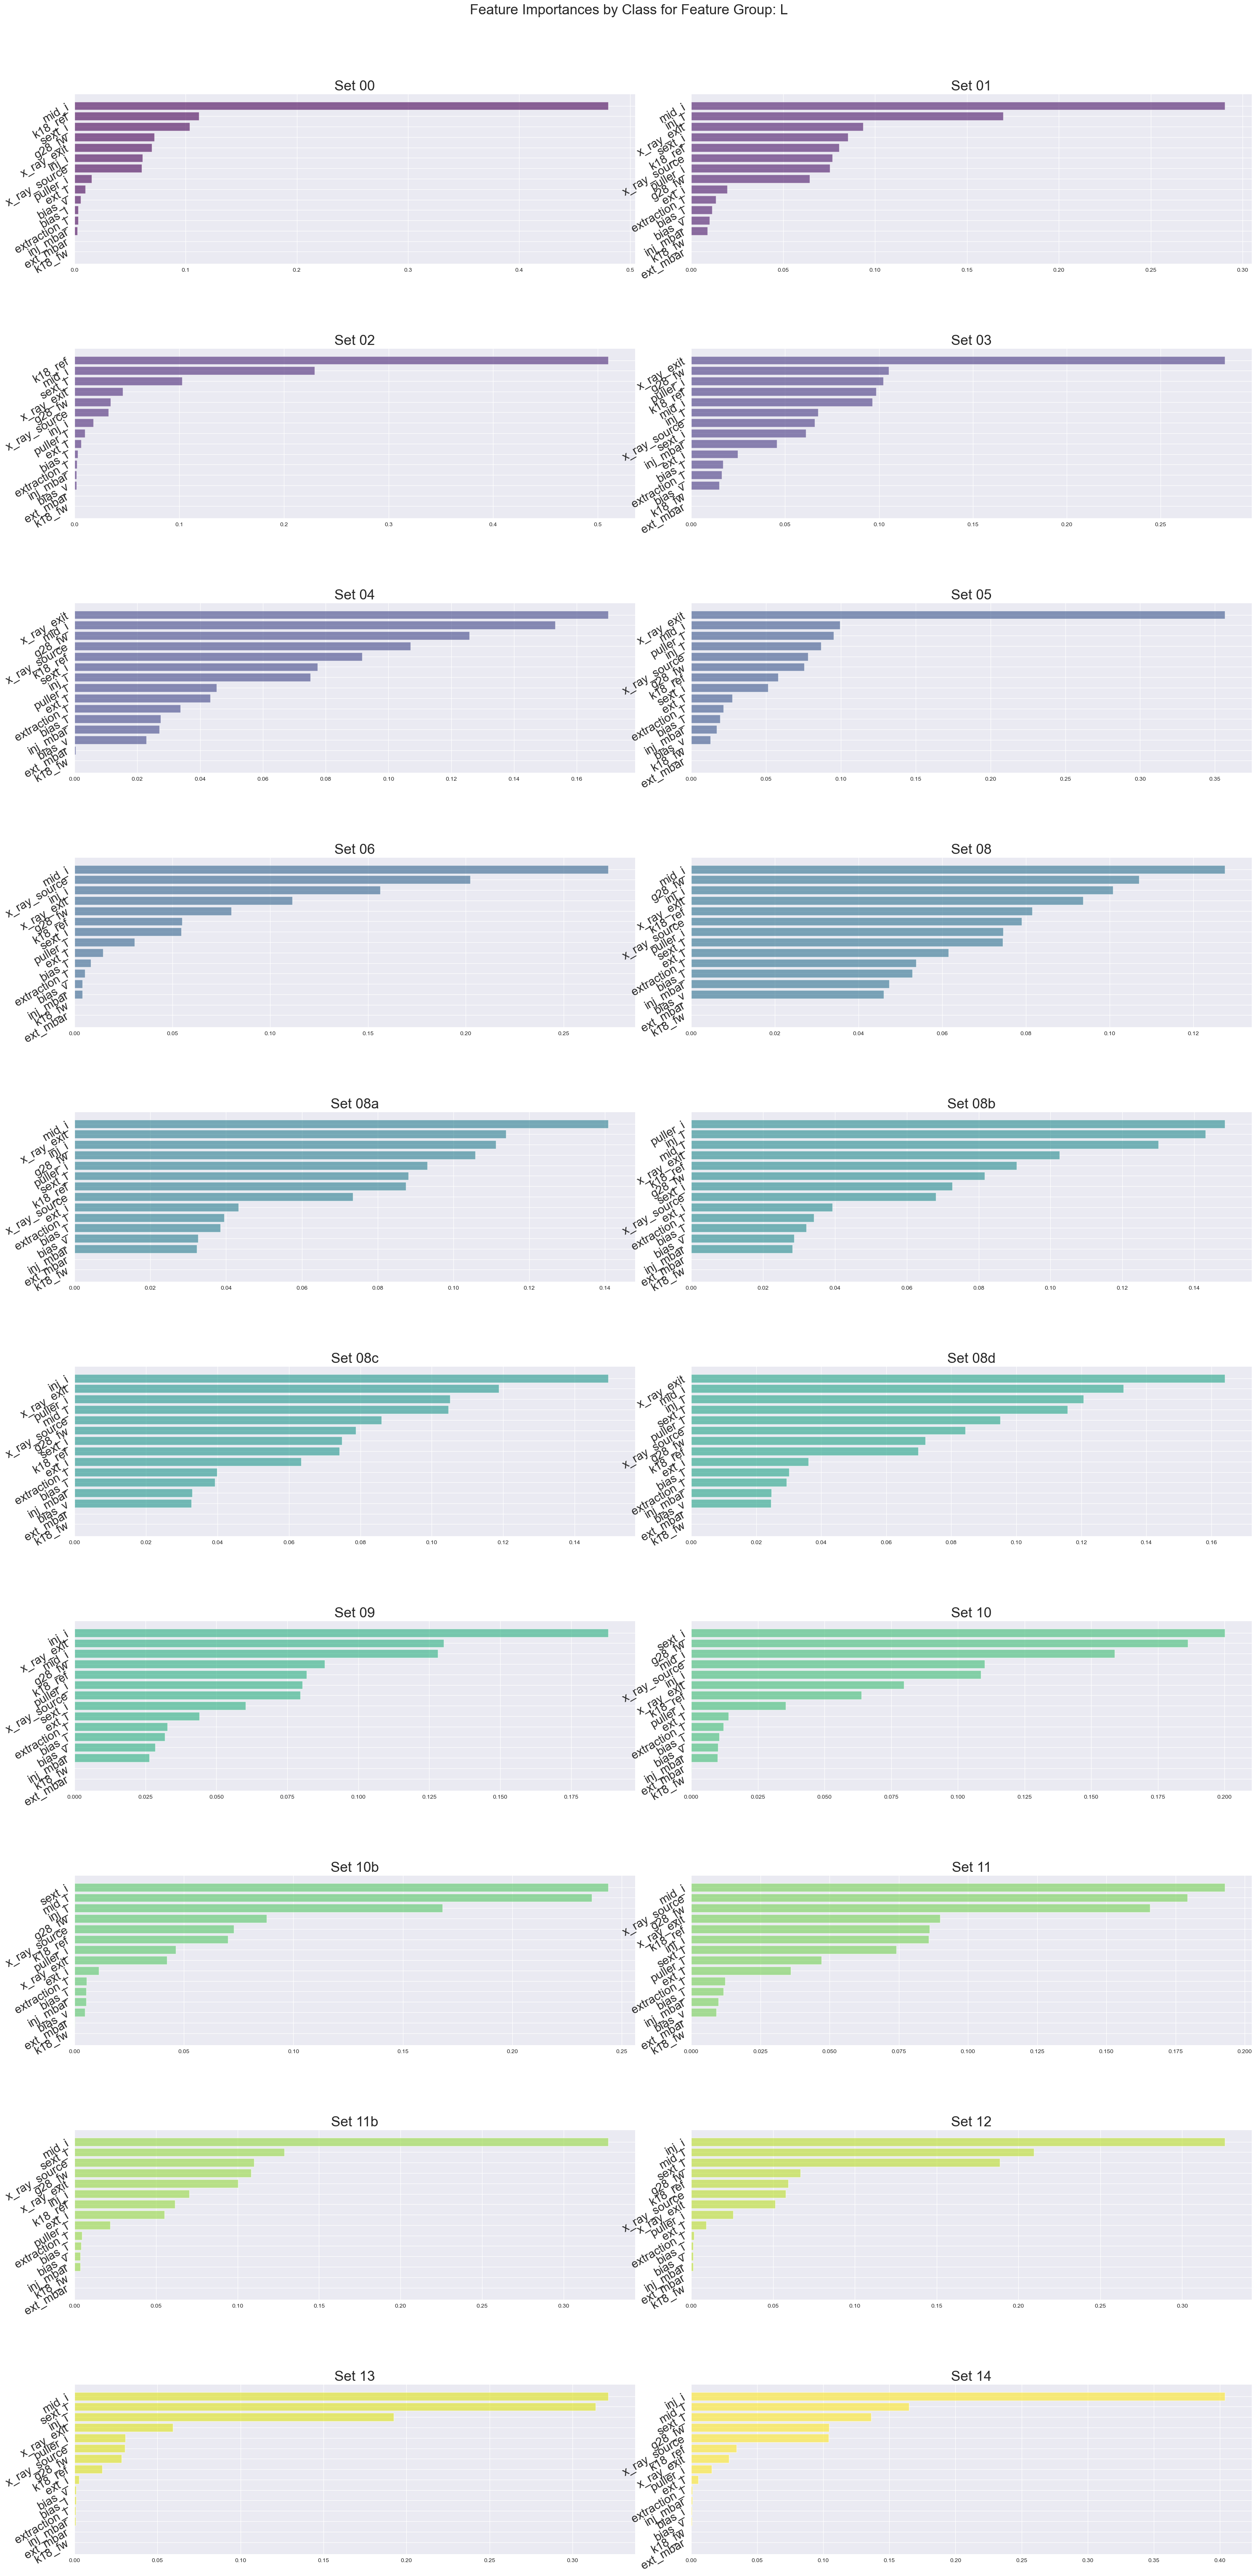

In [18]:
plot_one_vs_rest_feature_importances(datasetL, 'L')